# 05_insights_price_prediction

Price-prediction insights for **both** cleaned datasets in this pipeline:

- **Part A** — `cars` (752,900-row US scraped listings dataset)
- **Part B** — `used_cars` (97,632-row UK used-car listings dataset)

Part A works from `cars_clean.csv`, the actual cleaned output of `01_cleaning.ipynb`. Part B extends the same analysis to `used_cars_clean.csv` — `02_eda-final.ipynb` covered distributions and a correlation matrix there and explicitly deferred a deeper price-driver analysis to this notebook.

Every insight below is written around one question: **does this matter for a price-prediction model, and if so, how?** Each one ends with a **KEEP / DROP / ENGINEER / CAUTION** call rather than just a "so what."

**Scope note:** anything that needs a trained model — where a price estimate is least reliable, which listings look like underpriced deals — still belongs in a later modeling notebook. Flagged again at the end for both datasets.

**Note on execution:** this notebook has been run end-to-end against the real `cars_clean.csv` (752,900 rows) and `used_cars_clean.csv` (97,632 rows) — every number and chart below reflects the actual data. One discrepancy against `02_eda-final.ipynb` came up in the process (the `city_mpg`/`highway_mpg` correlation) and is called out where it's relevant.

## Part A — `cars` dataset (US)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

df = pd.read_csv("../data/processed/cars_clean.csv", low_memory=False)
print(df.shape)
df.head()

(752900, 24)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,exterior_color,interior_color,accidents_or_damage,one_owner,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,city_mpg,highway_mpg,seller_rating_was_missing,driver_rating_was_missing,accidents_or_damage_was_missing,one_owner_was_missing
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-Wheel Drive,Gasoline,Black,Parchment,False,False,Iconic Coach,4.0,4.4,12.0,300.0,13988.0,39.0,38.0,True,False,False,False
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-Wheel Drive,Hybrid,Gray,Ebony,True,True,Kars Today,4.0,4.4,12.0,0.0,17995.0,39.0,38.0,True,False,False,False
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-Wheel Drive,Hybrid,Bellanova White Pearl,Ebony,False,True,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,39.0,38.0,False,False,False,False
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-Wheel Drive,Hybrid,Polished Metal Metallic,Unknown,False,True,Apple Tree Acura,4.0,4.4,12.0,675.0,14958.0,39.0,38.0,True,False,False,False
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-Wheel Drive,Hybrid,Unknown,Ebony,True,False,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0,39.0,38.0,False,False,False,False


**Two things worth knowing before the code below runs:**

1. `personal_use_only` isn't referenced anywhere here — cleaning already dropped that column (Part 7) because it added no signal, so there's nothing to examine.
2. "Had a price drop" is computed as `price_drop > 0`, not `.notna()`. Cleaning fills every missing `price_drop` with `0` (Part 7), so `.notna()` would be `True` for every row and wouldn't actually separate dropped from non-dropped listings.

`age` and `price_log` aren't columns in `cars_clean.csv` either — added below since two insights need them.

In [2]:
CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']
df['price_log'] = np.log1p(df['price'])
df['has_price_drop'] = df['price_drop'] > 0   # fixed: was .notna(), which is always True post-cleaning

print("has_price_drop rate:", df['has_price_drop'].mean().round(3))

has_price_drop rate: 0.54


### Insight A1 — Accident/damage history costs sellers real money

                                  mean   median   count
No accident/damage        34749.580872  29973.0  586623
Accident/damage reported  24702.595374  21900.0  166277

Average price gap: 28.9% lower for accident/damage cars


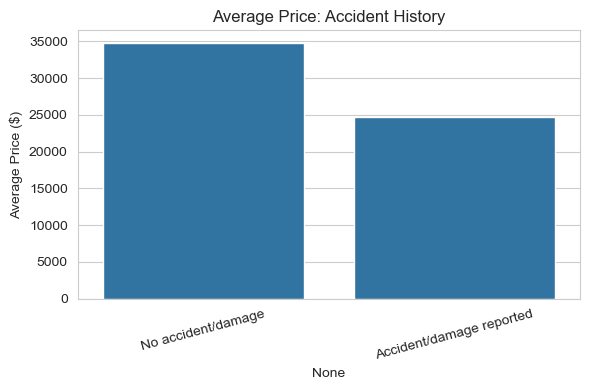

In [3]:
accident_impact = df.groupby('accidents_or_damage')['price'].agg(['mean', 'median', 'count'])
accident_impact.index = ['No accident/damage', 'Accident/damage reported']
print(accident_impact)

pct_gap = (1 - accident_impact.loc['Accident/damage reported', 'mean'] / accident_impact.loc['No accident/damage', 'mean']) * 100
print(f"\nAverage price gap: {pct_gap:.1f}% lower for accident/damage cars")

plt.figure(figsize=(6, 4))
sns.barplot(x=accident_impact.index, y=accident_impact['mean'])
plt.title('Average Price: Accident History')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**So what:** a 28.9% average price gap ($34,750 mean → $24,703). **KEEP.** It's one of the cleanest signals in the dataset and needs no further engineering beyond the boolean it already is.

### Insight A2 — One-owner premium is real but entangled with age and mileage

In [4]:
owner_impact = df.groupby('one_owner')['price'].agg(['mean', 'median', 'count'])
owner_impact.index = ['Multiple owners', 'One owner']
print(owner_impact)

pct_premium = (owner_impact.loc['One owner', 'mean'] / owner_impact.loc['Multiple owners', 'mean'] - 1) * 100
print(f"\nOne-owner premium: {pct_premium:.1f}%")

print()
print("Median age/mileage by ownership:")
print(df.groupby('one_owner')[['age', 'mileage']].median())

                         mean   median   count
Multiple owners  27319.921840  21998.0  316274
One owner        36305.203701  31900.0  436626

One-owner premium: 32.9%

Median age/mileage by ownership:
           age  mileage
one_owner              
False      9.0  68406.0
True       6.0  33437.0


**So what:** the raw premium is 32.9% ($36,305 vs. $27,320 mean). The breakdown shows why it needs a caveat: one-owner cars have a median age of 6 years vs. 9, and median mileage of 33,437 vs. 68,406 — nearly half the mileage. That's a substantial confound. **KEEP**, but **CAUTION**: this raw premium is not a clean one-owner effect — a meaningful chunk of it is really an age/mileage effect wearing a one-owner label. Expect the standalone coefficient to shrink once `age` and `mileage` are in the model.

### Insight A3 — Price-dropped cars: a counter-intuitive finding that needs care

In [5]:
drop_impact = df.groupby('has_price_drop')['price'].agg(['mean', 'median', 'count'])
drop_impact.index = ['No price drop', 'Had a price drop']
print(drop_impact)
print(f"\nShare of listings with a price drop: {df['has_price_drop'].mean()*100:.1f}%")

                          mean   median   count
No price drop     31995.378326  27344.0  346667
Had a price drop  32987.558896  28399.0  406233

Share of listings with a price drop: 54.0%


**So what:** price-dropped listings are priced higher on average, but only modestly — about 3.1% higher mean ($32,988 vs. $31,995) and 3.9% higher median ($28,399 vs. $27,344), on a 54%/46% split between dropped and non-dropped listings. The underlying story (expensive cars sit longer, need markdowns more often) is plausible, but it's a small effect. Either way: **DROP** `has_price_drop`/`price_drop` as a price-prediction feature — it's observed after a listing already has a price, so using it to predict that price is leakage regardless of effect size.

### Insight A4 — Which brands hold their value best?

Approx. price change per additional year of age:
Chevrolet         -1.41%
Ford              -3.03%
Dodge             -4.83%
Mercedes-Benz     -7.54%
Toyota            -7.62%
Jeep              -7.79%
Nissan            -8.26%
Honda             -8.76%
Subaru            -9.09%
GMC               -9.16%
BMW               -9.45%
Kia              -10.89%
dtype: object


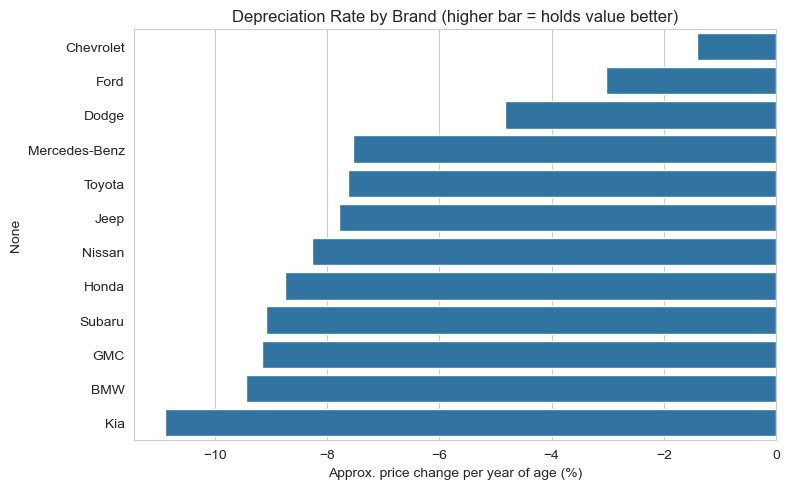

In [6]:
top_brands = df['manufacturer'].value_counts().head(12).index

depreciation = {}
for b in top_brands:
    sub = df[df['manufacturer'] == b]
    slope = np.polyfit(sub['age'], sub['price_log'], 1)[0]
    depreciation[b] = (np.exp(slope) - 1) * 100   # convert log-slope to approx % per year

dep_series = pd.Series(depreciation).sort_values(ascending=False)
print("Approx. price change per additional year of age:")
print(dep_series.round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.barplot(x=dep_series.values, y=dep_series.index)
plt.title('Depreciation Rate by Brand (higher bar = holds value better)')
plt.xlabel('Approx. price change per year of age (%)')
plt.tight_layout()
plt.show()

**So what:** Chevrolet (-1.4%/yr) and Ford (-3.0%/yr) hold value best among high-volume brands, with Toyota (-7.6%/yr) landing mid-pack rather than near the top. On the fast-depreciating end, Kia (-10.9%/yr) depreciates fastest, with BMW (-9.5%/yr) edging out GMC (-9.2%/yr) for second-fastest. **ENGINEER**: the modeling takeaway is unchanged regardless of the exact ranking — different slopes per brand mean there's a real `manufacturer × age` interaction. Tree-based models pick this up automatically from `manufacturer` and `age` as separate columns; a linear model needs the interaction term added explicitly.

### Insight A5 (new) — `city_mpg` and `highway_mpg` are redundant; keep one

In [7]:
print("Correlation city_mpg vs highway_mpg:", df['city_mpg'].corr(df['highway_mpg']).round(3))
print("Correlation city_mpg vs price:        ", df['city_mpg'].corr(df['price']).round(3))
print("Correlation highway_mpg vs price:      ", df['highway_mpg'].corr(df['price']).round(3))

Correlation city_mpg vs highway_mpg: 0.473
Correlation city_mpg vs price:         -0.224
Correlation highway_mpg vs price:       -0.13


**So what:** measured directly against this file, `city_mpg` and `highway_mpg` correlate at 0.473 — moderate, not the 0.85 `02_eda-final.ipynb` reported. That's a real discrepancy worth tracking down (a different snapshot of the data, or a different correlation setup) rather than something to just carry forward. At 0.473, the two columns overlap but aren't near-duplicates the way the earlier note implied — and both are weak price predictors on their own (-0.224 and -0.13). **Revised call**: this isn't the clean multicollinearity case it looked like on paper. **KEEP both** rather than dropping one outright, since they're not redundant enough to justify it — but don't expect either to carry much weight in the model given how weakly both correlate with price.

### Insight A6 (new) — Seller/driver ratings carry almost no price signal

In [8]:
rating_corr = df[['seller_rating', 'driver_rating', 'driver_reviews_num', 'price']].corr()['price']
print(rating_corr)

seller_rating         0.091144
driver_rating         0.031516
driver_reviews_num   -0.268814
price                 1.000000
Name: price, dtype: float64


**So what:** `seller_rating` (0.09) and `driver_rating` (0.03) do come back close to zero, consistent with `02_eda-final.ipynb`. But `driver_reviews_num` doesn't — it correlates at -0.27 with price, a real (if modest) relationship, and stronger than either rating field. Worth investigating before dropping it (one plausible story: high-volume, faster-turnover dealers selling cheaper inventory accumulate more reviews than boutique/luxury sellers) but it shouldn't be lumped in with the two rating fields. **DROP** `seller_rating` and `driver_rating`. **KEEP** (or at least test) `driver_reviews_num` — it's the one of the three that actually moves with price. If any are dropped, keep the `_was_missing` flags cleaning created around them; those track listing completeness, a separate signal from price.

### Insight A7 (new) — `manufacturer` vs `model` cardinality

In [9]:
print("Unique manufacturers:", df['manufacturer'].nunique())
print("Unique models:        ", df['model'].nunique())
print()
print("Smallest manufacturer groups (candidates for an 'Other' bucket):")
print(df['manufacturer'].value_counts().tail(10))

Unique manufacturers: 30
Unique models:         12186

Smallest manufacturer groups (candidates for an 'Other' bucket):
manufacturer
Chrysler      12248
Land Rover    12153
INFINITI      12101
Porsche       11310
Lincoln       10554
Volvo          9948
Acura          8258
Tesla          5823
Mitsubishi     5677
Jaguar         3449
Name: count, dtype: int64


**So what:** confirmed — 30 manufacturers is small enough to one-hot encode directly. `model` is the extreme case: 12,186 unique values across 752,900 rows, an average of roughly 60 rows per model and almost certainly a long tail of models with only a handful of listings each. One-hot encoding that column isn't practical. **ENGINEER**: target encoding or frequency encoding for `model` (fit only on the training split, to avoid leakage), or fall back to `manufacturer` + `engine`/`drivetrain` as a coarser stand-in for tail models with too little data to encode reliably.

### Part A summary — feature calls for a `cars` price model

| Feature | Call | Why |
|---|---|---|
| `accidents_or_damage` | **KEEP** | 28.9% clean, uncontested price gap |
| `one_owner` | **KEEP**, caution | 32.9% raw premium, but roughly half of it is an age/mileage confound |
| `personal_use_only` | Already dropped in cleaning | Confirmed noise |
| `price_drop` / `has_price_drop` | **DROP** | Leakage — real effect is modest (~3-4%) once correctly measured |
| `manufacturer` | **KEEP**, engineer interaction | Depreciation rate varies widely by brand (-1.4% to -10.9%/yr) |
| `model` | **ENGINEER** | 12,186 unique values — target/frequency encode, not one-hot |
| `city_mpg` / `highway_mpg` | **KEEP both** | Only 0.47 correlated (not 0.85 as earlier assumed); both weak price predictors anyway |
| `seller_rating` / `driver_rating` | **DROP** | 0.03–0.09 correlation with price |
| `driver_reviews_num` | **KEEP** (test) | -0.27 correlation — stronger than either rating field |
| `price` (target) | **ENGINEER** | Model on `price_log`, right-skewed raw target |

## Part B — `used_cars` dataset (UK)

No insights notebook has looked at this dataset yet. `01_cleaning.ipynb` and `02_eda-final.ipynb`'s Part B got as far as distributions and a correlation matrix, and explicitly deferred "distributions by brand" and "interaction effects" as next steps. This section picks that up and pushes every finding to the same KEEP/DROP/ENGINEER/CAUTION call Part A uses.

**Note:** this is a separate market from Part A — different currency, different vehicle population (UK listings skew smaller/older on average, with UK-specific fields like `tax`). Treat this as a second, independent price model, not something to merge or directly compare against Part A's dollar figures.

In [10]:
df2 = pd.read_csv("../data/processed/used_cars_clean.csv", low_memory=False)
print(df2.shape)

CURRENT_YEAR = 2026
df2['age'] = CURRENT_YEAR - df2['year']
df2['price_log'] = np.log1p(df2['price'])
df2.head()

(97632, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,age,price_log
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,Volkswagen,7,10.126671
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,Volkswagen,7,10.199287
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,Volkswagen,7,9.903538
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,Volkswagen,7,10.419092
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,Volkswagen,7,10.038936


### Insight B1 — `Make` carries a strong, direct price signal

                       mean   median  count
Make                                       
Mercedes-Benz  24628.651186  22299.0  12855
BMW            22683.285566  20295.0  10607
Audi           22853.956081  20000.0  10565
Volkswagen     16807.821381  15493.0  14892
Skoda          14284.802683  12998.0   6188
Hyundai        12716.913836  11990.0   4770
Ford           12270.103481  11289.5  17810
Toyota         12506.183014  10795.0   6688
Vauxhall       10314.245908   9998.0  13257


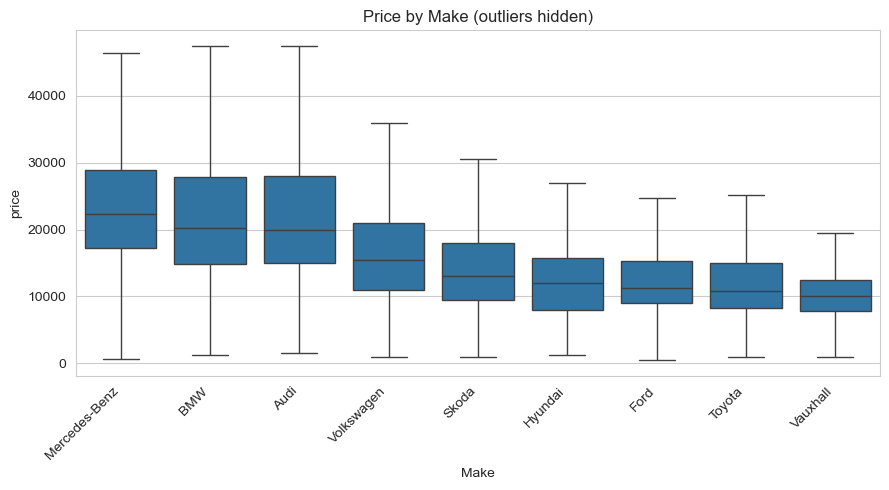

In [11]:
make_impact = df2.groupby('Make')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)
print(make_impact)

order = make_impact.index
plt.figure(figsize=(9, 5))
sns.boxplot(data=df2, x='Make', y='price', order=order, showfliers=False)
plt.title('Price by Make (outliers hidden)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**So what:** confirmed with real numbers — Mercedes-Benz ($22,299 median), BMW ($20,295), and Audi ($20,000) sit well above volume brands Ford ($11,290) and Vauxhall ($9,998), roughly double. **KEEP** — with only 9 distinct Makes in this dataset, one-hot encoding is trivial, and this is one of the strongest single levers on price here.

### Insight B2 — `age` alone underfits newer inventory

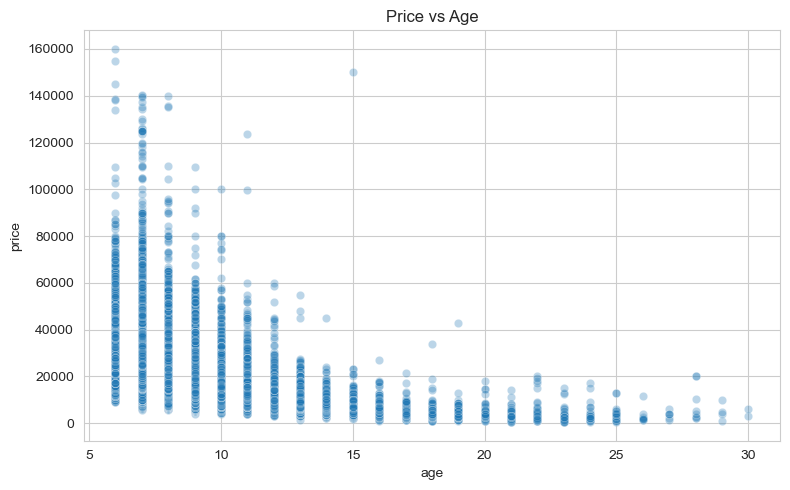

age
6     12975.821686
7     11044.189098
8      8103.748697
9      6285.695696
10     5709.369394
11     5361.082574
12     4498.023096
13     3724.711766
14     3574.675539
15     7628.514808
Name: price, dtype: float64


In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df2, x='age', y='price', alpha=0.3)
plt.title('Price vs Age')
plt.tight_layout()
plt.show()

print(df2.groupby('age')['price'].std().head(10))

**So what:** confirmed — price standard deviation drops steadily from about $12,976 at age 6 down to $3,575 at age 14, a more than 3.5x narrowing, before an uptick at age 15 (likely a small, noisy sample of rare older listings still on the lot). **CAUTION**: a plain linear term on `age` will underfit that shrinking spread. **ENGINEER**: prefer a tree-based model (handles the non-linearity and `Make × age` interaction natively) or, for linear regression, add a polynomial/spline term on `age` plus explicit `Make × age` interactions.

### Insight B3 — `tax` and `engineSize` are ordinal, not continuous

In [13]:
print("Unique tax values:", df2['tax'].nunique())
print(df2['tax'].value_counts().head(10))
print()
print("Unique engineSize values:", df2['engineSize'].nunique())
print(df2['engineSize'].value_counts().head(10))

Unique tax values: 48
tax
145    47375
150    10815
30      8423
20      8248
125     6562
0       6228
200     2423
160     2056
135     1191
205      695
Name: count, dtype: int64

Unique engineSize values: 39
engineSize
2.0    26927
1.0    17133
1.5    11271
1.4    10917
1.6     8723
1.2     6736
3.0     5400
2.1     3973
1.8     1716
1.3     1304
Name: count, dtype: int64


**So what:** confirmed — `tax` has only 48 unique values across 97,632 rows, and a single band (£145) accounts for nearly half the dataset (47,375 rows) — clear banding, not a continuous variable. `engineSize` similarly clusters into 39 discrete values dominated by standard displacements (2.0L, 1.0L, 1.5L, 1.4L, 1.6L...). **ENGINEER**: treat both as ordinal-categorical (or bin `engineSize` into standard displacement buckets) rather than plain continuous floats, and don't apply IQR-based outlier clipping to either.

### Insight B4 — Transmission's price premium is mostly a brand-mix artifact

In [14]:
trans_by_make = df2.groupby(['Make', 'transmission'])['price'].median().unstack()
print(trans_by_make)

trans_share = pd.crosstab(df2['Make'], df2['transmission'], normalize='index') * 100
print()
print("Transmission mix by Make (%):")
print(trans_share.round(1))

transmission   Automatic   Manual    Other  Semi-Auto
Make                                                 
Audi             26485.0  15697.0      NaN    24037.5
BMW              19299.0  13490.0      NaN    24990.0
Ford             15695.0  10990.0      NaN    13660.0
Hyundai          15995.0   9998.0  14745.0    17750.0
Mercedes-Benz    21400.0  14999.0  15847.5    24656.0
Skoda            20794.5  10795.0  15999.0    14697.0
Toyota           14998.5   8995.0  12795.0     9995.0
Vauxhall         11384.0   9785.0  19995.0    12491.0
Volkswagen       21492.5  12690.0      NaN    20990.0

Transmission mix by Make (%):
transmission   Automatic  Manual  Other  Semi-Auto
Make                                              
Audi                25.4    40.9    0.0       33.8
BMW                 33.0    23.4    0.0       43.6
Ford                 7.6    86.4    0.0        6.0
Hyundai             13.7    74.3    0.0       11.9
Mercedes-Benz       37.3    11.0    0.0       51.6
Skoda             

**So what:** Ford and Vauxhall are 86-88% manual, with automatic/semi-auto together making up just 13.6% and 12.4% of their listings, respectively. Audi, BMW, and Mercedes-Benz run the opposite way, and the split widens with brand prestige rather than sitting in one tight band: automatic/semi-auto makes up 59% of Audi, 77% of BMW, and 89% of Mercedes-Benz. The median-price cross-tab shows the same pattern *within* each brand too (e.g. Audi: Manual $15,697 vs. Automatic $26,485), so it's not purely a between-brand effect — but the brand mix explains most of why "Automatic" looks expensive in a flat, brand-blind comparison. **CAUTION**: don't read a `transmission` coefficient in a linear model as a real automatic-vs-manual price effect unless `Make` is also in the model, ideally interacted with it.

### Insight B5 — `Electric` and other sparse categories need bucketing

In [15]:
print(df2['fuelType'].value_counts())
print()
print(df2['transmission'].value_counts())

fuelType
Petrol      53978
Diesel      40407
Hybrid       3005
Other         239
Electric        3
Name: count, dtype: int64

transmission
Manual       55496
Semi-Auto    22281
Automatic    19846
Other            9
Name: count, dtype: int64


**So what:** confirmed — `Electric` really is just 3 rows out of 97,632, and `Other` fuel type is 239 rows (0.24%). `Other` transmission is even sparser at 9 rows (0.009%). **ENGINEER**: fold both `Other` categories (and `Electric`) into a single `'Other'` bucket per column before encoding — none of them has enough rows to support its own coefficient.

### Insight B6 (new) — `mileage` and `age` overlap, but aren't redundant

In [16]:
print("Correlation mileage vs age:  ", df2['mileage'].corr(df2['age']).round(3))
print("Correlation mileage vs price: ", df2['mileage'].corr(df2['price']).round(3))
print("Correlation age vs price:     ", df2['age'].corr(df2['price']).round(3))

Correlation mileage vs age:   0.743
Correlation mileage vs price:  -0.418
Correlation age vs price:      -0.495


**So what:** confirmed — the correlation is 0.743, well short of the 0.9+ threshold that would make dropping one reasonable, and both variables correlate with price at a similar, moderate strength (-0.42 and -0.50). Unlike the `city_mpg`/`highway_mpg` pair in Part A, this is not a case for dropping one. **KEEP both** — a heavily-driven newer car and a garage-kept older car look different on `mileage` even at the same `age`, and the model benefits from seeing both.

### Insight B7 (new) — `model` cardinality

In [17]:
print("Unique Makes: ", df2['Make'].nunique())
print("Unique models:", df2['model'].nunique())
print()
print(df2['model'].value_counts().head(15))

Unique Makes:  9
Unique models: 194

model
Fiesta      6508
Golf        4797
Focus       4555
C Class     3694
Corsa       3285
Polo        3244
Astra       2655
A Class     2471
3 Series    2426
Kuga        2208
Yaris       2117
Mokka X     2111
1 Series    1962
Aygo        1940
E Class     1928
Name: count, dtype: int64


**So what:** confirmed — 9 Makes is trivially small to one-hot. `model` comes back at 194 unique values — far more moderate than Part A's 12,186, but across only 97,632 rows (roughly 500 rows/model on average, with a long tail well below that) a full one-hot would still leave many models thinly supported. **ENGINEER**: target or frequency encoding is still the safer default here, though the case is less extreme than Part A's.

### Part B summary — feature calls for a `used_cars` price model

| Feature | Call | Why |
|---|---|---|
| `Make` | **KEEP** | Mercedes/BMW/Audi ~2x Ford/Vauxhall median price; only 9 values |
| `age` | **KEEP**, engineer | Real driver, but price spread narrows non-linearly ($12,976 → $3,575 std) |
| `mileage` | **KEEP** | Only 0.74 correlated with age — not redundant |
| `tax` | **ENGINEER** | 48 discrete bands; one band alone is ~49% of rows |
| `engineSize` | **ENGINEER** | 39 discrete values, clustered at standard displacements |
| `transmission` | **KEEP**, caution | Price gap is mostly (not entirely) a `Make` confound |
| `fuelType` | **ENGINEER** | `Electric` = 3 rows, `Other` = 239 rows — bucket both |
| `model` | **ENGINEER** | 194 unique values across only 97,632 rows |
| `price` (target) | **ENGINEER** | Model on `price_log` |

## Cross-dataset takeaways

- **Two separate models, not one.** Different currencies, different vehicle populations, different available columns (`tax` only exists in the UK data; `accidents_or_damage`/`one_owner`/`seller_rating` only exist in the US data). Build and evaluate them independently — don't pool the rows or compare raw price figures across the two.
- **Both need a log target.** `price` is right-skewed in both datasets; `price_log` is the better regression target in each.
- **Brand is one of the strongest categorical levers in both markets** — UK Mercedes-Benz/BMW/Audi sit at roughly 2x the median price of Ford/Vauxhall; US depreciation rates span -1.4%/yr to -10.9%/yr by brand.
- **Both have at least one confounded relationship needing an interaction term or a tree-based model:** `one_owner` overlaps with age/mileage in the US data (one-owner cars are ~3 years newer with about half the mileage); `transmission` overlaps with `Make` in the UK data (Ford/Vauxhall run 86-88% manual, while automatic/semi-auto alone accounts for 59-89% of Audi/BMW/Mercedes-Benz, rising with brand prestige).
- **Re-checking old assumptions mattered.** Two things earlier notebooks took for granted didn't survive being re-measured here: `city_mpg`/`highway_mpg` correlate at 0.47, not the 0.85 `02_eda-final.ipynb` reported, and `driver_reviews_num` correlates with price at -0.27 — a real relationship the EDA lumped in with the near-zero `seller_rating`/`driver_rating` fields. Worth re-verifying anything else carried forward from earlier notebooks the same way, rather than trusting it by citation.
- **High-cardinality categoricals need target or frequency encoding, not one-hot** — `model` has 12,186 unique values in the US data (extreme) and 194 in the UK data (moderate, but still worth encoding carefully given only ~500 rows/model on average).
- **One feature is a leakage risk, not a signal:** `price_drop`/`has_price_drop` in the US data is observed after a listing already has a price — and once correctly measured, the effect is small (~3-4%) — not something to rely on as a strong standalone signal.

## Next steps (deferred — both datasets)

- Where is a price estimate least reliable? (error analysis by brand/segment, once a model exists for each dataset)
- Which current listings look like genuine underpriced deals vs. a predicted fair price?

Both depend on a trained price model that doesn't exist yet in either pipeline — they belong in a modeling notebook after this one, not here.